In [1]:
# =========================
# 02 MODELING
# =========================

import xarray as xr
import numpy as np

# Load processed data
temp_basin = xr.open_dataarray(r"P:\snowmelt_stochastic_model\data\processed\temp_basin.nc")

# Extract temperature
T = temp_basin

print(T)

<xarray.DataArray 't2m' (time: 1826)> Size: 7kB
[1826 values with dtype=float32]
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 15kB 2018-01-01 2018-01-02 ... 2022-12-31
    expver   (time) <U4 29kB ...


In [2]:
# =========================
# DETERMINISTIC SNOWMELT (DDF)
# =========================

DDF = 3.5  # mm/day/°C
T_base = 0.0

melt_det = DDF * (T - T_base)
melt_det = melt_det.where(melt_det > 0, 0)

print("Deterministic melt computed")

Deterministic melt computed


In [3]:
# =========================
# RUNOFF
# =========================

k = 0.7

runoff_det = k * melt_det

print("Runoff computed")

Runoff computed


In [4]:
# =========================
# AR(1) STOCHASTIC MODEL
# =========================

np.random.seed(42)

n = len(T)

phi = 0.7  # persistence

# Base noise
eta = np.random.normal(0, 1, n)

# AR1 process
epsilon_ar1 = np.zeros(n)

for t in range(1, n):
    epsilon_ar1[t] = phi * epsilon_ar1[t-1] + eta[t]

# Simple variance model
sigma = 0.3 * melt_det + 1

# Stochastic melt
melt_stoch_ar1 = melt_det + sigma * epsilon_ar1
melt_stoch_ar1 = melt_stoch_ar1.where(melt_stoch_ar1 > 0, 0)

print("AR1 stochastic model ready")

AR1 stochastic model ready


In [5]:
# =========================
# TEMP-TRIGGERED JUMP MODEL (CLEAN)
# =========================

np.random.seed(42)

T_vals = T.values
n = len(T_vals)

phi = 0.7

eta = np.random.normal(0, 1, n)

# Trigger condition
jump_condition = T_vals > 5
random_trigger = np.random.rand(n) < 0.15

jumps = jump_condition & random_trigger

# Controlled jump scale
jump_scale = 2 + 0.2 * np.maximum(T_vals, 0)
jump_sizes = np.random.normal(0, jump_scale, n)

# AR1 + jumps
epsilon_jump = np.zeros(n)

for t in range(1, n):
    jump_term = jump_sizes[t] if jumps[t] else 0
    epsilon_jump[t] = phi * epsilon_jump[t-1] + eta[t] + jump_term

# Final melt
melt_temp_jump = melt_det + sigma * epsilon_jump
melt_temp_jump = melt_temp_jump.clip(min=0, max=80)

print("Temperature-triggered jump model ready")

Temperature-triggered jump model ready


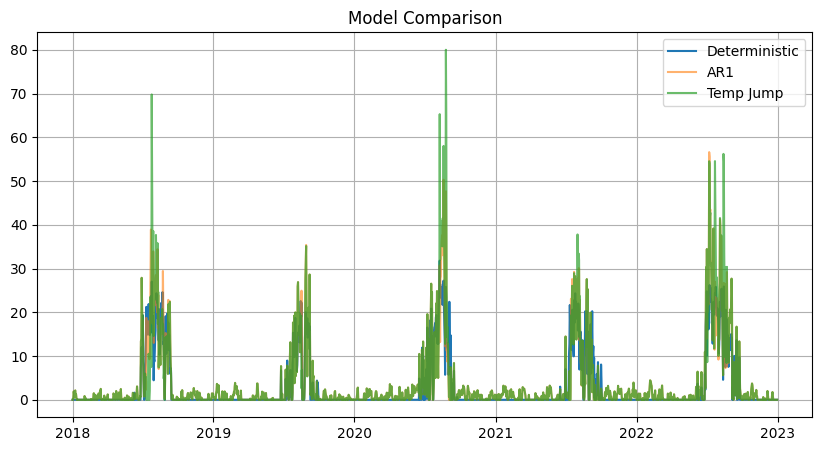

In [6]:
# =========================
# QUICK MODEL CHECK
# =========================

import matplotlib.pyplot as plt

time = melt_det['time']

plt.figure(figsize=(10,5))

plt.plot(time, melt_det, label="Deterministic")
plt.plot(time, melt_stoch_ar1, label="AR1", alpha=0.6)
plt.plot(time, melt_temp_jump, label="Temp Jump", alpha=0.7)

plt.legend()
plt.grid()
plt.title("Model Comparison")

plt.show()

In [7]:
# =========================
# RUNOFF (ALL MODELS)
# =========================

k = 0.7  # runoff coefficient

runoff_det = k * melt_det
runoff_ar1 = k * melt_stoch_ar1
runoff_temp_jump = k * melt_temp_jump

print("Runoff computed for all models")

Runoff computed for all models


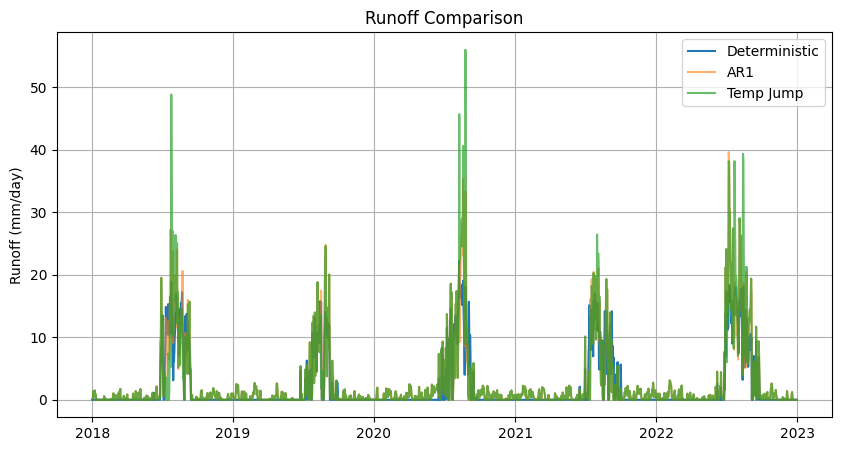

In [8]:
# =========================
# RUNOFF COMPARISON PLOT
# =========================

import matplotlib.pyplot as plt

time = melt_det['time']

plt.figure(figsize=(10,5))

plt.plot(time, runoff_det, label="Deterministic")
plt.plot(time, runoff_ar1, label="AR1", alpha=0.6)
plt.plot(time, runoff_temp_jump, label="Temp Jump", alpha=0.7)

plt.title("Runoff Comparison")
plt.ylabel("Runoff (mm/day)")
plt.legend()
plt.grid()

plt.show()

In [9]:
# =========================
# BASIC STATISTICS (MELT + RUNOFF)
# =========================

import pandas as pd
import numpy as np

def stats(data, name):
    return {
        "Model": name,
        "Mean": float(np.nanmean(data)),
        "Std": float(np.nanstd(data)),
        "Max": float(np.nanmax(data)),
        "P90": float(np.nanpercentile(data, 90)),
        "P95": float(np.nanpercentile(data, 95))
    }

results = []

# Melt stats
results.append(stats(melt_det.values, "Melt - Deterministic"))
results.append(stats(melt_stoch_ar1.values, "Melt - AR1"))
results.append(stats(melt_temp_jump.values, "Melt - Temp Jump"))

# Runoff stats
results.append(stats(runoff_det.values, "Runoff - Deterministic"))
results.append(stats(runoff_ar1.values, "Runoff - AR1"))
results.append(stats(runoff_temp_jump.values, "Runoff - Temp Jump"))

df = pd.DataFrame(results)

print(df)

                    Model      Mean       Std        Max        P90        P95
0    Melt - Deterministic  2.808745  6.369570  31.801315  14.161606  19.443649
1              Melt - AR1  3.628501  7.681598  56.604266  14.063707  22.007741
2        Melt - Temp Jump  3.794421  8.715655  80.000000  13.946926  23.357729
3  Runoff - Deterministic  1.966121  4.458699  22.260920   9.913124  13.610555
4            Runoff - AR1  2.539951  5.377119  39.622986   9.844595  15.405419
5      Runoff - Temp Jump  2.656094  6.100958  56.000000   9.762848  16.350410


In [11]:
# =========================
# CREATE OUTPUT DIRECTORIES
# =========================

import os

base_path = r"P:\snowmelt_stochastic_model\outputs"

folders = [
    "figures",
    "tables"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Output folders ready")

Output folders ready


In [12]:
# Save stats
df.to_csv(r"P:\snowmelt_stochastic_model\outputs\tables\model_stats.csv", index=False)

print("Stats saved")

Stats saved


In [13]:
# =========================
# SAVE MODEL OUTPUTS (CLEAN)
# =========================

import xarray as xr

# Combine all melt outputs into one dataset
ds_melt = xr.Dataset({
    "melt_det": melt_det,
    "melt_ar1": melt_stoch_ar1,
    "melt_temp_jump": melt_temp_jump
})

# Combine runoff outputs
ds_runoff = xr.Dataset({
    "runoff_det": runoff_det,
    "runoff_ar1": runoff_ar1,
    "runoff_temp_jump": runoff_temp_jump
})

# Save
ds_melt.to_netcdf(r"P:\snowmelt_stochastic_model\data\processed\melt_models.nc")
ds_runoff.to_netcdf(r"P:\snowmelt_stochastic_model\data\processed\runoff_models.nc")

print("All model outputs saved")

All model outputs saved


In [14]:
# Save sigma (important for stochastic models)
xr.DataArray(sigma, coords={"time": melt_det.time}).to_netcdf(
    r"P:\snowmelt_stochastic_model\data\processed\sigma.nc"
)

print("Sigma saved")

Sigma saved
